# Lesson 01 — Tree Prediction Geometry and Terminology

## Lesson objective and prerequisites

**Objective.** Explain a regression tree as a piecewise-constant prediction function and use the terms *feature*, *threshold*, *branch*, *internal node*, *leaf*, *region*, and *leaf prediction* precisely.

**Prerequisites.** Python, NumPy and pandas basics, and experience calling a decision-tree model. Knowledge of CART internals is not required.

**Stopping point.** Translate fluently among a threshold rule, a two-leaf tree diagram, and a piecewise-constant prediction plot. This lesson deliberately does not search for the best split.

## Mental model: a leaf stores one shared prediction

A regression tree first uses feature thresholds to route an observation to a leaf. Think of each leaf as a region, or bucket, with one numerical label attached to it. Once an observation reaches that leaf, the model returns the attached value; it does not calculate or store a separate value for each future observation.

In Python-like pseudocode, a two-leaf tree behaves like this:

```python
if med_inc <= threshold:
    return left_leaf_prediction
return right_leaf_prediction
```

Therefore, two observations routed to the same leaf receive the same prediction even when their feature values and true target values differ. During training, a common regression-tree choice is to set the shared leaf prediction to the mean target value of the training observations in that region.

## California Housing columns and units

Each row describes a California census block group rather than one household or one house. The monetary columns are scaled so that the dataset contains small numerical values:

| Column | Model role | Stored unit | Example |
|---|---|---:|---:|
| `MedInc` | Feature: median household income in the block group | \$10,000 | `3.5` means about \$35,000 |
| `MedHouseVal` | Continuous target: median house value in the block group | \$100,000 | `2.4` means about \$240,000 |

These are historical values derived from the 1990 U.S. Census, not present-day dollar amounts. The target was capped near \$500,000 in the source data, which appears here as a maximum around `5.00001`; block groups at that ceiling did not necessarily have identical uncapped median house values.

## Load and inspect California Housing

We use `MedInc` as the single feature and `MedHouseVal` as the continuous target. Before selecting a small slice, `describe()` confirms the number of available block groups and the numerical range of both columns.

In [1]:
from sklearn.datasets import fetch_california_housing

# Request a labeled pandas frame so feature and target names remain visible.
housing = fetch_california_housing(as_frame=True)

# Keep only the one feature and continuous target used in this lesson.
housing_rows = housing.frame.loc[:, ["MedInc", "MedHouseVal"]]

# Check the row count, center, spread, and observed range before sampling.
housing_rows.describe()

,MedInc,MedHouseVal
count,20640.000000,20640.000000
mean,3.870671,2.068558
std,1.899822,1.153956
min,0.499900,0.149990
25%,2.563400,1.196000
50%,3.534800,1.797000
75%,4.743250,2.647250
max,15.000100,5.000010


## Select a deterministic 12-row slice

A small table makes the threshold and leaf calculations inspectable by hand. We sort all rows by `MedInc`, retain each original `source_row` identifier, and select 12 evenly spaced **rank positions** from the sorted table. These positions are evenly spaced by row order rather than by income value; the fixed procedure makes the real-data slice reproducible.

In [2]:
import numpy as np

# Preserve original row identifiers and use them to break income ties reproducibly.
sorted_rows = (
    housing_rows.reset_index(names="source_row")
    .sort_values(by=["MedInc", "source_row"])
    .reset_index(drop=True)
)
print(f"Total sorted rows: {len(sorted_rows)}")

# Select 12 evenly spaced rank positions across the sorted real rows.
rank_positions = np.linspace(
    0,
    len(sorted_rows) - 1,
    num=12,
    dtype=int,
)

# Display the positions so the selection rule is visible and auditable.
print(rank_positions)

# Materialize the selected rows as the small table used for hand reasoning.
housing_slice = sorted_rows.iloc[rank_positions].reset_index(drop=True)
housing_slice

Total sorted rows: 20640
[    0  1876  3752  5628  7505  9381 11257 13133 15010 16886 18762 20639]


,source_row,MedInc,MedHouseVal
0,73,0.4999,0.675
1,241,1.8472,1.370
2,3789,2.2756,2.214
3,19601,2.6406,1.297
4,5841,3.0179,2.725
5,5606,3.3427,1.542
6,19373,3.7031,1.733
7,6743,4.1136,2.799
8,16665,4.6071,2.399
9,8554,5.2500,2.472


## Manual threshold and leaf predictions

We manually choose `MedInc = 4.0`, representing a block-group median income of about \$40,000.
This threshold is intentionally transparent rather than optimized.

- **Left region:** `MedInc ≤ 4.0`
- **Right region:** `MedInc > 4.0`

Every row belongs to exactly one region. The mean `MedHouseVal` within each region becomes that
 leaf's shared prediction.

In [3]:
# Use an interpretable $40,000 cutoff; best-split search is outside this lesson.
THRESHOLD = 4.0

# Mark each row according to the threshold rule.
left_mask = housing_slice["MedInc"] <= THRESHOLD
right_mask = housing_slice["MedInc"] > THRESHOLD

# Check that the regions cover every row without overlapping
assert (left_mask | right_mask).all()
assert not (left_mask & right_mask).any()
assert left_mask.sum() == 7
assert right_mask.sum() == 5

# The mean target in each region becomes that leaf's shared prediction.
left_leaf_prediction = housing_slice.loc[left_mask, "MedHouseVal"].mean()
right_leaf_prediction = housing_slice.loc[right_mask, "MedHouseVal"].mean()

left_leaf_prediction, right_leaf_prediction

(np.float64(1.650857142857143), np.float64(3.2340000000000004))

### Feature and target arrays

The visualization uses `x` for the visible `MedInc` feature values and `y` for the corresponding observed `MedHouseVal` targets. Converting the columns to NumPy arrays preserves their row order and makes element-wise thresholding explicit.

In [8]:
# Map the visible table columns to the x and y notation used below.
x = housing_slice["MedInc"].to_numpy()
y = housing_slice["MedHouseVal"].to_numpy()
x, y

(array([ 0.4999,  1.8472,  2.2756,  2.6406,  3.0179,  3.3427,  3.7031,
         4.1136,  4.6071,  5.25  ,  6.2946, 15.0001]),
 array([0.675, 1.37 , 2.214, 1.297, 2.725, 1.542, 1.733, 2.799, 2.399,
        2.472, 4.5  , 4.   ]))

## Two views of the same regression stump

The left panel shows the observed targets and the threshold that partitions them. The right panel
 replaces every target in a region with that region's mean target.

The horizontal lines are constant because each leaf stores one shared prediction. The jump at
 `MedInc = 4.0` is the same boundary represented by the tree's internal threshold node.

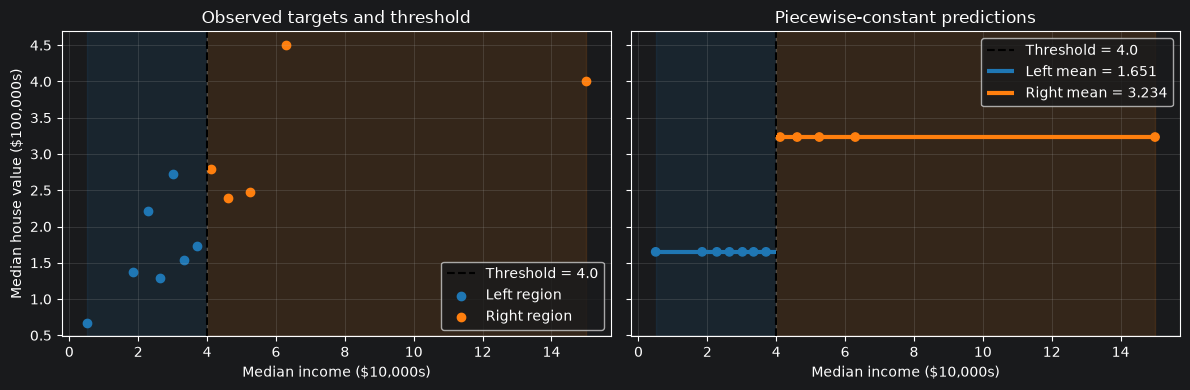

In [5]:
import matplotlib.pyplot as plt

# Convert the visible feature and target columns to NumPy arrays for plotting.
is_left = x <= THRESHOLD

# Assign one of the two leaf values to every visible observation.
predictions = np.where(
    is_left,
    left_leaf_prediction,
    right_leaf_prediction,
)

# One prediction per row, using no more than two leaf values.
assert predictions.shape == y.shape
assert np.unique(predictions).size <= 2

fig, (target_ax, prediction_ax) = plt.subplots(
    1,
    2,
    figsize=(12, 4),
    sharex=True,
    sharey=True,
)

for ax in (target_ax, prediction_ax):
    # Shade the two feature regions and mark their boundary.
    ax.axvspan(x.min(), THRESHOLD, color="tab:blue", alpha=0.12)
    ax.axvspan(THRESHOLD, x.max(), color="tab:orange", alpha=0.12)
    ax.axvline(THRESHOLD, color="black", linestyle="--", label="Threshold = 4.0")
    ax.set_xlabel(r"Median income (\$10,000s)")
    ax.grid(alpha=0.25)

# Left panel: real target values.
target_ax.scatter(x[is_left], y[is_left], color="tab:blue", label="Left region")
target_ax.scatter(x[~is_left], y[~is_left], color="tab:orange", label="Right region")
target_ax.set_title("Observed targets and threshold")
target_ax.set_ylabel(r"Median house value (\$100,000s)")
target_ax.legend()

# Right panel: the same model expressed as two horizontal steps.
prediction_ax.hlines(
    left_leaf_prediction,
    x.min(),
    THRESHOLD,
    color="tab:blue",
    linewidth=3,
    label=f"Left mean = {left_leaf_prediction:.3f}",
)
prediction_ax.hlines(
    right_leaf_prediction,
    THRESHOLD,
    x.max(),
    color="tab:orange",
    linewidth=3,
    label=f"Right mean = {right_leaf_prediction:.3f}",
)
prediction_ax.scatter(
    x,
    predictions,
    color=np.where(is_left, "tab:blue", "tab:orange"),
)
prediction_ax.set_title("Piecewise-constant predictions")
prediction_ax.legend()

fig.tight_layout()
plt.show()

## Threshold notation and symbol-to-code mapping

For observation $i$, let $x_i$ be its `MedInc` feature and $y_i$ its observed `MedHouseVal` target. Given threshold $t$, the two regions are

$$
R_L(t) = \{i : x_i \le t\}, \qquad R_R(t) = \{i : x_i > t\}.
$$

Each leaf stores the mean target of the rows in its region:

$$
\mu_L = \frac{1}{|R_L|} \sum_{i \in R_L} y_i, \qquad
\mu_R = \frac{1}{|R_R|} \sum_{i \in R_R} y_i.
$$

The stump prediction is therefore

$$
\hat{y}(x) =
\begin{cases}
\mu_L, & x \le t, \\
\mu_R, & x > t.
\end{cases}
$$

| Symbol | Meaning | Notebook code |
|---|---|---|
| $x_i$ | income feature for row $i$ | `housing_slice["MedInc"]` |
| $y_i$ | observed target for row $i$ | `housing_slice["MedHouseVal"]` |
| $t$ | manual threshold | `THRESHOLD` |
| $R_L(t)$, $R_R(t)$ | left and right regions | `left_mask`, `right_mask` |
| $\mu_L$, $\mu_R$ | shared leaf predictions | `left_leaf_prediction`, `right_leaf_prediction` |
| $\hat{y}$ | prediction for each row | `predictions` |

## Implement a one-feature stump predictor

`predict_stump` packages the plotted threshold rule into a reusable function. It accepts a one-dimensional income array, the threshold, and the two leaf predictions; it returns one prediction per input value with the same array shape. The function performs prediction only—it does not choose the threshold or calculate the leaf means.

In [6]:
def predict_stump(
    med_inc: np.ndarray,
    threshold: float,
    left_prediction: float,
    right_prediction: float,
) -> np.ndarray:
    """Return one leaf prediction for every income value."""
    # Apply the same threshold rule to every income value at once.
    return np.where(med_inc <= threshold, left_prediction, right_prediction)

In [7]:
stump_predictions = predict_stump(
    x,
    THRESHOLD,
    left_leaf_prediction,
    right_leaf_prediction,
)

# One output for every input row.
assert stump_predictions.shape == x.shape

# A two-leaf stump can return at most two distinct values.
assert np.unique(stump_predictions).size <= 2

# The reusable function must reproduce the predictions used in the plot.
assert np.array_equal(stump_predictions, predictions)

stump_predictions

array([1.65085714, 1.65085714, 1.65085714, 1.65085714, 1.65085714,
       1.65085714, 1.65085714, 3.234     , 3.234     , 3.234     ,
       3.234     , 3.234     ])